**Formulación de un sistema de clasificación supervisada para hepatitis C en humanos.**

Modelos y Simulación de Sistemas II 2026-1.

CARGA DE LIBRERÍAS

In [1]:
!pip install ucimlrepo #--- Necesario para importar la base de datos desde el repositorio UCI ML.

ERROR: Invalid requirement: '#---': Expected package name at the start of dependency specifier
    #---
    ^


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from scipy import stats

#--- Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

#--- Particiones, validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    GridSearchCV, learning_curve, cross_validate,
)

#--- Evaluación de desempeño
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
)

#--- Balanceo de clases
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

#--- Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

#--- Selección y extracción de características
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import umap.umap_ as umap


CARGA DE DATOS

In [3]:
#--- Dataset HCV (ID=571) desde repositorio UCI ML.
crudo = fetch_ucirepo(id=571)

#--- Predictores
X = crudo.data.features.copy()

#--- Variable objetivo/respuesta
y = crudo.data.targets.copy()

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeras filas de y:")
display(y.head())

#--- Información general del dataset
print("\n---- METADATA ----\n")
print(crudo.metadata)
print("\n----- FEATURES -----\n")
display(crudo.variables)

Dimensiones X: (615, 12)
Dimensiones y: (615, 1)

Primeras filas de X:


,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6



Primeras filas de y:


,Category
0,0=Blood Donor
1,0=Blood Donor
2,0=Blood Donor
3,0=Blood Donor
4,0=Blood Donor



---- METADATA ----

{'uci_id': 571, 'name': 'HCV data', 'repository_url': 'https://archive.ics.uci.edu/dataset/571/hcv+data', 'data_url': 'https://archive.ics.uci.edu/static/public/571/data.csv', 'abstract': 'The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 615, 'num_features': 12, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['Category'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5D612', 'creators': ['Ralf Lichtinghagen', 'Frank Klawonn', 'Georg Hoffmann'], 'intro_paper': {'ID': 237, 'type': 'NATIVE', 'title': 'Using machine learning techniques to generate laboratory diagnostic pathways—a case study', 'authors': 'Georg F.

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,NaN,Patient ID,NaN,no
1,Age,Feature,Integer,Age,NaN,years,no
2,Sex,Feature,Binary,Sex,NaN,NaN,no
3,ALB,Feature,Continuous,NaN,NaN,NaN,yes
4,ALP,Feature,Continuous,NaN,NaN,NaN,yes
5,AST,Feature,Continuous,NaN,NaN,NaN,yes
6,BIL,Feature,Continuous,NaN,NaN,NaN,no
7,CHE,Feature,Continuous,NaN,NaN,NaN,no
8,CHOL,Feature,Continuous,NaN,NaN,NaN,yes
9,CREA,Feature,Continuous,NaN,NaN,NaN,no


EXPLORACIÓN INICIAL DE DATOS


----- DISTRIBUCIÓN DE CLASES -----



,Frecuencia,Porcentaje (%)
Category,,
0=Blood Donor,533,86.67
3=Cirrhosis,30,4.88
1=Hepatitis,24,3.90
2=Fibrosis,21,3.41
0s=suspect Blood Donor,7,1.14


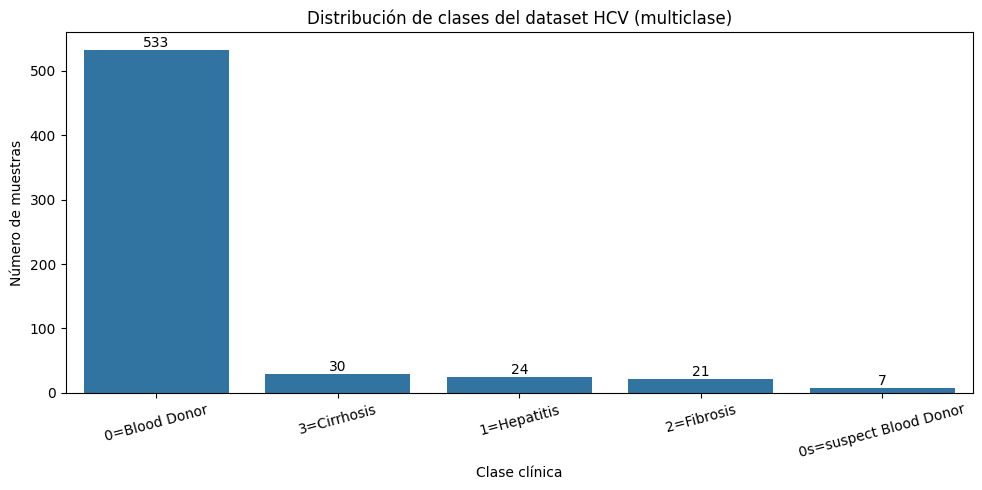

In [4]:
#--- Datos en formato dataframe.
import os
HCV = X.copy()
HCV["Category"] = y

#--- Distribución de clases
conteo_clases = HCV["Category"].value_counts()
porcentaje_clases = (HCV["Category"].value_counts(normalize=True)*100)
tabla_clases = pd.DataFrame({"Frecuencia": conteo_clases,"Porcentaje (%)": porcentaje_clases.round(2)})
print("\n----- DISTRIBUCIÓN DE CLASES -----\n")
display(tabla_clases)

#--- Visualización de la distribución de clases
os.makedirs("figs", exist_ok=True)
plt.figure(figsize=(10,5))
ax = sns.countplot(data=HCV,x="Category",order=conteo_clases.index)
plt.title("Distribución de clases del dataset HCV (multiclase)")
plt.xlabel("Clase clínica")
plt.ylabel("Número de muestras")
plt.xticks(rotation=15)
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{int(altura)}",(p.get_x() + p.get_width()/2., altura),ha="center",va="bottom",fontsize=10)
plt.tight_layout()
plt.savefig("figs/multi_dist_clases.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
#--- Valores de faltantes
faltantes = HCV.isnull().sum()
porcentaje_faltantes = (HCV.isnull().mean()*100)
tabla_faltantes = pd.DataFrame({"Valores faltantes": faltantes,"Porcentaje (%)": porcentaje_faltantes.round(2)})
tabla_faltantes = tabla_faltantes.sort_values(by="Porcentaje (%)",ascending=False)
print("\n----- VALORES FALTANTES -----\n")
display(tabla_faltantes)


----- VALORES FALTANTES -----



,Valores faltantes,Porcentaje (%)
ALP,18,2.93
CHOL,10,1.63
ALB,1,0.16
PROT,1,0.16
ALT,1,0.16
AST,0,0.00
Sex,0,0.00
Age,0,0.00
BIL,0,0.00
CREA,0,0.00


In [6]:
#--- Codificación de la variable respuesta
label_encoder = LabelEncoder() #--- Codificador de etiquetas para y
y_encoded = label_encoder.fit_transform(y)
print("\nClases codificadas:\n")
for i, clase in enumerate(label_encoder.classes_):
    print(f"{i} -> {clase}")


#--- Predictores categóricos y numéricos
categoricos = X.select_dtypes(include=["object"]).columns
numericos = X.select_dtypes(exclude=["object"]).columns
print("\nPredictores categóricos:")
print(categoricos)
print("\nPredictores numéricos:")
print(numericos)


Clases codificadas:

0 -> 0=Blood Donor
1 -> 0s=suspect Blood Donor
2 -> 1=Hepatitis
3 -> 2=Fibrosis
4 -> 3=Cirrhosis

Predictores categóricos:
Index(['Sex'], dtype='str')

Predictores numéricos:
Index(['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT',
       'ALT'],
      dtype='str')


c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38176\332438109.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricos = X.select_dtypes(include=["object"]).columns


PREPROCESAMIENTO

In [7]:
#--- pipeline para predictores categóricos: aplicamos imputación con la moda y se utiliza codificación one-hot.
transformador_categorico = Pipeline(steps=[("Imputación", SimpleImputer(strategy="most_frequent")),("Codificación", OneHotEncoder(drop="if_binary"))])

#--- pipeline para predictores numéricos: aplicamos imputación con la mediana y se escalan los datos.
transformador_numerico = Pipeline(steps=[("Imputación", SimpleImputer(strategy="median")),("Escalado", StandardScaler())])

#--- preprocesador
preprocesador = ColumnTransformer(transformers=[("categórico", transformador_categorico, categoricos),("numérico", transformador_numerico, numericos)])


VISUALIZACIÓN DEL PREPROCESAMIENTO

Diagrama de flujo estático del preprocesamiento. Refleja la lógica del `ColumnTransformer`: rama categórica (imputación por moda + *one-hot*) y rama numérica (imputación por mediana + estandarización), que se unen en una única matriz lista para el modelo.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

def caja(x, y, texto, color, w=3.4, h=0.9, fs=10, bold=False):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                                boxstyle="round,pad=0.08,rounding_size=0.12",
                                linewidth=1.2, edgecolor="#34495E", facecolor=color))
    ax.text(x, y, texto, ha="center", va="center", fontsize=fs,
            fontweight="bold" if bold else "normal", color="#1B2631")
    return (x, y, w, h)

def flecha(p_from, p_to):
    x0, y0, _, h0 = p_from
    x1, y1, _, h1 = p_to
    ax.add_patch(FancyArrowPatch((x0, y0 - h0/2), (x1, y1 + h1/2),
                                 arrowstyle="-|>", mutation_scale=16,
                                 linewidth=1.4, color="#34495E"))

CAT, NUM, TOP, OUT = "#AED6F1", "#A9DFBF", "#FAD7A0", "#D7BDE2"

top  = caja(5, 9.2, "Predictores  X\n(categóricos + numéricos)", TOP, w=6, h=1.0, fs=11, bold=True)

cat0 = caja(2.6, 7.4, "Categóricos\n(dtype = object)", CAT, fs=10, bold=True)
cat1 = caja(2.6, 5.7, "SimpleImputer\nstrategy = 'most_frequent'", CAT)
cat2 = caja(2.6, 4.0, "OneHotEncoder\ndrop = 'if_binary'", CAT)

num0 = caja(7.4, 7.4, "Numéricos", NUM, fs=10, bold=True)
num1 = caja(7.4, 5.7, "SimpleImputer\nstrategy = 'median'", NUM)
num2 = caja(7.4, 4.0, "StandardScaler", NUM)

out  = caja(5, 2.0, "ColumnTransformer\n→  X preprocesada", OUT, w=6, h=1.0, fs=11, bold=True)

for a, b in [(top, cat0), (top, num0), (cat0, cat1), (cat1, cat2),
             (num0, num1), (num1, num2), (cat2, out), (num2, out)]:
    flecha(a, b)

ax.annotate("siguiente etapa del pipeline:  SMOTE / ADASYN  →  Clasificador",
            xy=(5, 0.7), ha="center", va="center", fontsize=9.5, style="italic",
            color="#566573",
            bbox=dict(boxstyle="round,pad=0.4", fc="#F2F3F4", ec="#AAB7B8", ls="--"))

ax.set_title("Flujo de preprocesamiento — Pipeline HCV", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

TRAIN-TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2,stratify=y_encoded,random_state=98)
print("\nDimensiones conjunto de entrenamiento:", X_train.shape)
print("Dimensiones conjunto de prueba:", X_test.shape)

#--- Validación cruzada repetida (3 folds x 5 repeticiones = 15 mediciones). Se baja a 3 folds para evitar que clases minoritarias queden con 0-3 muestras en algún fold (SMOTE necesita al menos k_neighbors+1 muestras por clase).
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=98)


Dimensiones conjunto de entrenamiento: (492, 12)
Dimensiones conjunto de prueba: (123, 12)


In [9]:
#--- conteo de clases en train (informativo)
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
conteo_train = dict(zip(unique_tr, counts_tr))
print("Conteo por clase en train:", conteo_train)

#--- estrategia de sobremuestreo como CALLABLE (no dict fijo).
#--- En CV con clases muy raras, algunos folds pueden no contener la clase 1.
#--- Un dict fijo crashea ("class X not present"); el callable se evalua fold por fold
#--- usando solo las clases realmente presentes. Cada minoritaria sube hasta 30.
#--- Se baja el techo de 60 a 30: con k_neighbors=1 (forzado por la clase mas rara
#--- que tiene solo 6 muestras de train), un target de 60 genera 54 sinteticas casi
#--- duplicadas para esa clase e inunda al modelo, empujandolo a sobreajustar.
def sampling_strategy_controlado(y):
    unique, counts = np.unique(y, return_counts=True)
    return {int(k): max(int(v), 30) for k, v in zip(unique, counts)}

print("Sampling strategy (callable) evaluado sobre y_train:", sampling_strategy_controlado(y_train))


Conteo por clase en train: {np.int64(0): np.int64(426), np.int64(1): np.int64(6), np.int64(2): np.int64(19), np.int64(3): np.int64(17), np.int64(4): np.int64(24)}
Sampling strategy (callable) evaluado sobre y_train: {0: 426, 1: 30, 2: 30, 3: 30, 4: 30}


In [10]:
#--- Evualuación de desempeño en train y test (para diagnosticar sobreajuste)
def metricas_clasificacion(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    print("Accuracy:", round(acc, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print("F1 Macro:", round(f1, 4))
    print("Precision Macro:", round(precision, 4))
    print("Recall Macro:", round(recall, 4))

#--- evaluación dual train vs test para detectar overfitting
def evaluar_train_test(modelo, nombre):
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    print(f"\n========= {nombre} =========")
    print("REPORTE DE CLASIFICACIÓN (TEST)")
    print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_, zero_division=0))
    print(f"--- {nombre} TRAIN ---")
    metricas_clasificacion(y_train, y_pred_train)
    print(f"--- {nombre} TEST ---")
    metricas_clasificacion(y_test, y_pred_test)
    f1_tr = f1_score(y_train, y_pred_train, average="macro", zero_division=0)
    f1_te = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    print(f"GAP F1 (train-test): {round(f1_tr - f1_te, 4)}")

ENTRENAMIENTO DE MODELOS.

1. **Regresión Logística.**

In [11]:
#--- pipeline para regresión logística con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. Regresión Logística
pipeline_logit_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", LogisticRegression(max_iter=1000))])

#--- pipeline para regresión logística con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. Regresión Logística
pipeline_logit_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", LogisticRegression(max_iter=1000))])

#--- ajuste de hiperparámetros
hp_logit = {"classifier__C": [0.01, 0.1, 1, 10, 100],"classifier__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"]}
malla_logit_smote = GridSearchCV(estimator=pipeline_logit_smote,param_grid=hp_logit,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_logit_adasyn = GridSearchCV(estimator=pipeline_logit_adasyn,param_grid=hp_logit,scoring="f1_macro",cv=cv,n_jobs=-1)

In [12]:
#--- entrenamiento
malla_logit_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['lbfgs', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [13]:
#--- entrenamiento
malla_logit_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['lbfgs', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [14]:
#--- resultados
print("Mejores hiperparámetros Logit con SMOTE:\n")
print(malla_logit_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_logit_smote.best_score_.round(4))

print("\nMejores hiperparámetros Logit con ADASYN:\n")
print(malla_logit_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_logit_adasyn.best_score_.round(4))

Mejores hiperparámetros Logit con SMOTE:

{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

Mejor F1 Macro CV:
0.6093

Mejores hiperparámetros Logit con ADASYN:

{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

Mejor F1 Macro CV:
0.6102


In [15]:
#--- predicciones y evaluación train vs test
evaluar_train_test(malla_logit_smote, "Logit SMOTE")
evaluar_train_test(malla_logit_adasyn, "Logit ADASYN")


========= Logit SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.95      1.00      0.97       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       1.00      0.40      0.57         5
            2=Fibrosis       1.00      0.75      0.86         4
           3=Cirrhosis       1.00      0.67      0.80         6

              accuracy                           0.94       123
             macro avg       0.79      0.56      0.64       123
          weighted avg       0.95      0.94      0.94       123

--- Logit SMOTE TRAIN ---
Accuracy: 0.9431
Balanced Accuracy: 0.7262
F1 Macro: 0.7537
Precision Macro: 0.7998
Recall Macro: 0.7262
--- Logit SMOTE TEST ---
Accuracy: 0.9431
Balanced Accuracy: 0.5633
F1 Macro: 0.6403
Precision Macro: 0.7894
Recall Macro: 0.5633
GAP F1 (train-test): 0.1135

========= Logit ADASYN =========
REPORTE DE CLASIFICACIÓN (TEST)
 

2. **K-Vecinos Más Cercanos (k-NN Classification).**

In [16]:
#--- pipeline para kNN con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. kNN classification
pipeline_knn_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", KNeighborsClassifier())])

#--- pipeline para kNN con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. kNN classification
pipeline_knn_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", KNeighborsClassifier())])

#--- ajuste de hiperparametros (solo weights="uniform"; con "distance" cada punto
#--- de train queda como su propio vecino dominante --> train F1 = 1.0 y gap > 0.4).
hp_knn = {"classifier__n_neighbors": [5,7,9,11,15,21],"classifier__weights": ["uniform"]}
malla_knn_smote = GridSearchCV(estimator=pipeline_knn_smote,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_knn_adasyn = GridSearchCV(estimator=pipeline_knn_adasyn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

In [17]:
#--- entrenamiento
malla_knn_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [5, 7, ...], 'classifier__weights': ['uniform']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [18]:
#--- entrenamiento
malla_knn_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [5, 7, ...], 'classifier__weights': ['uniform']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [19]:
#--- resultados
print("Mejores hiperparámetros k-NN con SMOTE:\n")
print(malla_knn_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_knn_smote.best_score_.round(4))

print("\nMejores hiperparámetros k-NN con ADASYN:\n")
print(malla_knn_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_knn_adasyn.best_score_.round(4))

Mejores hiperparámetros k-NN con SMOTE:

{'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}

Mejor F1 Macro CV:
0.5746

Mejores hiperparámetros k-NN con ADASYN:

{'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}

Mejor F1 Macro CV:
0.5467


In [20]:
#--- predicciones y evaluación train vs test
evaluar_train_test(malla_knn_smote, "k-NN SMOTE")
evaluar_train_test(malla_knn_adasyn, "k-NN ADASYN")


========= k-NN SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.93      0.99      0.96       107
0s=suspect Blood Donor       0.25      1.00      0.40         1
           1=Hepatitis       0.50      0.20      0.29         5
            2=Fibrosis       1.00      0.50      0.67         4
           3=Cirrhosis       1.00      0.17      0.29         6

              accuracy                           0.90       123
             macro avg       0.74      0.57      0.52       123
          weighted avg       0.91      0.90      0.88       123

--- k-NN SMOTE TRAIN ---
Accuracy: 0.9228
Balanced Accuracy: 0.6252
F1 Macro: 0.6432
Precision Macro: 0.7302
Recall Macro: 0.6252
--- k-NN SMOTE TEST ---
Accuracy: 0.9024
Balanced Accuracy: 0.5715
F1 Macro: 0.5195
Precision Macro: 0.736
Recall Macro: 0.5715
GAP F1 (train-test): 0.1237

========= k-NN ADASYN =========
REPORTE DE CLASIFICACIÓN (TEST)
      

3. **Bosque Aleatorio.**

In [21]:
#--- pipeline para random forest con SMOTE
pipeline_rf_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", RandomForestClassifier(random_state=98))])

#--- pipeline para random forest con ADASYN
pipeline_rf_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", RandomForestClassifier(random_state=98))])

#--- ajuste de hiperparametros.
#--- Se reabre la grilla: V3 anterior tenia max_depth<=7 y min_samples_leaf>=5, lo que
#--- subajustaba RF (caia de F1~0.85 a ~0.67). Ahora se permite max_depth hasta 9 y
#--- min_samples_leaf desde 2 (V2 ganaba con depth=7-9, leaf=1, n_est=50). Se quitan
#--- min_samples_split (redundante con min_samples_leaf) y max_features=0.5 (rompe la
#--- decorrelacion del bagging). La regularizacion la controla min_samples_leaf>=2.
hp_rf = {"classifier__n_estimators": [100,200,500],"classifier__max_depth": [5,7,9,None],"classifier__min_samples_leaf": [2,5,10],"classifier__max_features": ["sqrt"]}
malla_rf_smote = GridSearchCV(estimator=pipeline_rf_smote,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_rf_adasyn = GridSearchCV(estimator=pipeline_rf_adasyn,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

In [22]:
#--- entrenamiento
malla_rf_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 7, ...], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the hig

In [23]:
#--- entrenamiento
malla_rf_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 7, ...], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the hig

In [24]:
#--- resultados
print("Mejores hiperparámetros Random Forest con SMOTE:\n")
print(malla_rf_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_rf_smote.best_score_.round(4))

print("\nMejores hiperparámetros Random Forest con ADASYN:\n")
print(malla_rf_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_rf_adasyn.best_score_.round(4))

Mejores hiperparámetros Random Forest con SMOTE:

{'classifier__max_depth': 9, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}

Mejor F1 Macro CV:
0.6046

Mejores hiperparámetros Random Forest con ADASYN:

{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 200}

Mejor F1 Macro CV:
0.5807


In [25]:
#--- predicciones y evaluación train vs test
evaluar_train_test(malla_rf_smote, "Random Forest SMOTE")
evaluar_train_test(malla_rf_adasyn, "Random Forest ADASYN")


========= Random Forest SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.96      1.00      0.98       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       1.00      0.40      0.57         5
            2=Fibrosis       0.80      1.00      0.89         4
           3=Cirrhosis       1.00      0.67      0.80         6

              accuracy                           0.95       123
             macro avg       0.75      0.61      0.65       123
          weighted avg       0.95      0.95      0.94       123

--- Random Forest SMOTE TRAIN ---
Accuracy: 0.9695
Balanced Accuracy: 0.845
F1 Macro: 0.8782
Precision Macro: 0.9419
Recall Macro: 0.845
--- Random Forest SMOTE TEST ---
Accuracy: 0.9512
Balanced Accuracy: 0.6133
F1 Macro: 0.6475
Precision Macro: 0.7511
Recall Macro: 0.6133
GAP F1 (train-test): 0.2307

========= Random Forest ADASYN =========
REP

4. **Máquina de Vectores de Soporte (SVM).**

In [26]:
#--- pipeline para SVC con SMOTE
pipeline_svc_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", SVC(random_state=98))])

#--- pipeline para SVC con ADASYN
pipeline_svc_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", SVC(random_state=98))])

#--- ajuste de hiperparámetros
hp_svm = {"classifier__C": [0.01, 0.1, 1, 10, 100], "classifier__kernel": ["linear", "poly", "rbf", "sigmoid"], "classifier__gamma": ["scale", "auto"]}
malla_svc_smote = GridSearchCV(estimator=pipeline_svc_smote,param_grid=hp_svm,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_svc_adasyn = GridSearchCV(estimator=pipeline_svc_adasyn,param_grid=hp_svm,scoring="f1_macro",cv=cv,n_jobs=-1)

In [27]:
#--- entrenamiento
malla_svc_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [28]:
#--- entrenamiento
malla_svc_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [29]:
#--- resultados
print("Mejores hiperparámetros SVC con SMOTE:\n")
print(malla_svc_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_svc_smote.best_score_.round(4))

print("\nMejores hiperparámetros SVC con ADASYN:\n")
print(malla_svc_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_svc_adasyn.best_score_.round(4))

Mejores hiperparámetros SVC con SMOTE:

{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Mejor F1 Macro CV:
0.5869

Mejores hiperparámetros SVC con ADASYN:

{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Mejor F1 Macro CV:
0.5825


In [30]:
#--- predicciones y evaluación train vs test
evaluar_train_test(malla_svc_smote, "SVC SMOTE")
evaluar_train_test(malla_svc_adasyn, "SVC ADASYN")


========= SVC SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.97      1.00      0.99       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       0.75      0.60      0.67         5
            2=Fibrosis       1.00      0.75      0.86         4
           3=Cirrhosis       1.00      0.83      0.91         6

              accuracy                           0.96       123
             macro avg       0.74      0.64      0.68       123
          weighted avg       0.96      0.96      0.96       123

--- SVC SMOTE TRAIN ---
Accuracy: 0.9451
Balanced Accuracy: 0.747
F1 Macro: 0.7818
Precision Macro: 0.8432
Recall Macro: 0.747
--- SVC SMOTE TEST ---
Accuracy: 0.9593
Balanced Accuracy: 0.6367
F1 Macro: 0.6838
Precision Macro: 0.7445
Recall Macro: 0.6367
GAP F1 (train-test): 0.0979

========= SVC ADASYN =========
REPORTE DE CLASIFICACIÓN (TEST)
           

5. **Perceptrón Multicapa (MLP).**

In [31]:
#--- pipeline para MLP con SMOTE
pipeline_mlp_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", MLPClassifier(max_iter=1000,random_state=98))])

#--- pipeline para MLP con ADASYN
pipeline_mlp_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", MLPClassifier(max_iter=1000,random_state=98))])

#--- ajuste de hiperparametros. Se restringe a 1 sola capa oculta y alpha alto
#--- porque con 492 muestras de train (y minoritarias muy pequenas) las redes con
#--- 2 capas memorizaban (gap MLP ADASYN llegaba a 0.26). 1 capa + alpha>=0.1 deja
#--- una red mas estable.
hp_ann = {"classifier__hidden_layer_sizes": [(10,),(20,),(30,)],"classifier__activation": ["tanh", "relu"], "classifier__alpha": [0.1, 1, 10]}
malla_mlp_smote = GridSearchCV(estimator=pipeline_mlp_smote,param_grid=hp_ann,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_mlp_adasyn = GridSearchCV(estimator=pipeline_mlp_adasyn,param_grid=hp_ann,scoring="f1_macro",cv=cv,n_jobs=-1)

In [32]:
#--- entrenamiento
malla_mlp_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__activation': ['tanh', 'relu'], 'classifier__alpha': [0.1, 1, ...], 'classifier__hidden_layer_sizes': [(10,), (20,), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [33]:
#--- entrenamiento
malla_mlp_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__activation': ['tanh', 'relu'], 'classifier__alpha': [0.1, 1, ...], 'classifier__hidden_layer_sizes': [(10,), (20,), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [34]:
#--- resultados
print("Mejores hiperparámetros MLP con SMOTE:\n")
print(malla_mlp_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_mlp_smote.best_score_.round(4))

print("\nMejores hiperparámetros MLP con ADASYN:\n")
print(malla_mlp_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_mlp_adasyn.best_score_.round(4))

Mejores hiperparámetros MLP con SMOTE:

{'classifier__activation': 'tanh', 'classifier__alpha': 0.1, 'classifier__hidden_layer_sizes': (30,)}

Mejor F1 Macro CV:
0.6196

Mejores hiperparámetros MLP con ADASYN:

{'classifier__activation': 'tanh', 'classifier__alpha': 0.1, 'classifier__hidden_layer_sizes': (20,)}

Mejor F1 Macro CV:
0.611


In [35]:
#--- predicciones y evaluación train vs test
evaluar_train_test(malla_mlp_smote, "MLP SMOTE")
evaluar_train_test(malla_mlp_adasyn, "MLP ADASYN")


========= MLP SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.97      0.98      0.98       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       0.57      0.80      0.67         5
            2=Fibrosis       1.00      0.75      0.86         4
           3=Cirrhosis       1.00      0.67      0.80         6

              accuracy                           0.94       123
             macro avg       0.71      0.64      0.66       123
          weighted avg       0.95      0.94      0.94       123

--- MLP SMOTE TRAIN ---
Accuracy: 0.9939
Balanced Accuracy: 0.9684
F1 Macro: 0.9715
Precision Macro: 0.9785
Recall Macro: 0.9684
--- MLP SMOTE TEST ---
Accuracy: 0.9431
Balanced Accuracy: 0.6396
F1 Macro: 0.6601
Precision Macro: 0.7087
Recall Macro: 0.6396
GAP F1 (train-test): 0.3114

========= MLP ADASYN =========
REPORTE DE CLASIFICACIÓN (TEST)
         

6. **Gradient Boosting (HistGradientBoosting).**

In [36]:
#--- pipeline para Histogram Gradient Boosting con SMOTE
#--- alternativa a Random Forest con regularizacion nativa (l2) y early stopping.
pipeline_hgb_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", HistGradientBoostingClassifier(early_stopping=True,n_iter_no_change=10,random_state=98))])

#--- pipeline para Histogram Gradient Boosting con ADASYN
pipeline_hgb_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),("classifier", HistGradientBoostingClassifier(early_stopping=True,n_iter_no_change=10,random_state=98))])

#--- ajuste de hiperparametros mas tensado: la version anterior dejaba gap=0.27 con train F1~0.97.
#--- Cambios: lr mas chico (0.01-0.05) frena la velocidad de fit; min_samples_leaf=[30,50,80]
#--- evita que los ultimos arboles memoricen muestras minoritarias; max_iter=100 limita el numero
#--- total de boosters; max_depth=3 mantiene splits superficiales.
hp_hgb = {"classifier__max_iter": [100, 200],"classifier__learning_rate": [0.01, 0.05],"classifier__max_depth": [3],"classifier__l2_regularization": [10.0, 100.0],"classifier__min_samples_leaf": [30, 50, 80]}
malla_hgb_smote = GridSearchCV(estimator=pipeline_hgb_smote,param_grid=hp_hgb,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_hgb_adasyn = GridSearchCV(estimator=pipeline_hgb_adasyn,param_grid=hp_hgb,scoring="f1_macro",cv=cv,n_jobs=-1)

In [37]:
#--- entrenamiento
malla_hgb_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__l2_regularization': [10.0, 100.0], 'classifier__learning_rate': [0.01, 0.05], 'classifier__max_depth': [3], 'classifier__max_iter': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher,

In [38]:
#--- entrenamiento
malla_hgb_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__l2_regularization': [10.0, 100.0], 'classifier__learning_rate': [0.01, 0.05], 'classifier__max_depth': [3], 'classifier__max_iter': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the higher,

In [39]:
#--- resultados
print("Mejores hiperparámetros HGB con SMOTE:\n")
print(malla_hgb_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_hgb_smote.best_score_.round(4))

print("\nMejores hiperparámetros HGB con ADASYN:\n")
print(malla_hgb_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_hgb_adasyn.best_score_.round(4))

Mejores hiperparámetros HGB con SMOTE:

{'classifier__l2_regularization': 10.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__max_iter': 200, 'classifier__min_samples_leaf': 30}

Mejor F1 Macro CV:
0.5854

Mejores hiperparámetros HGB con ADASYN:

{'classifier__l2_regularization': 10.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__max_iter': 100, 'classifier__min_samples_leaf': 50}

Mejor F1 Macro CV:
0.5594


In [40]:
#--- predicciones y evaluación train vs test
evaluar_train_test(malla_hgb_smote, "HGB SMOTE")
evaluar_train_test(malla_hgb_adasyn, "HGB ADASYN")


========= HGB SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.98      1.00      0.99       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       0.75      0.60      0.67         5
            2=Fibrosis       0.60      0.75      0.67         4
           3=Cirrhosis       1.00      0.67      0.80         6

              accuracy                           0.95       123
             macro avg       0.67      0.60      0.62       123
          weighted avg       0.95      0.95      0.95       123

--- HGB SMOTE TRAIN ---
Accuracy: 0.9878
Balanced Accuracy: 0.9378
F1 Macro: 0.9493
Precision Macro: 0.9639
Recall Macro: 0.9378
--- HGB SMOTE TEST ---
Accuracy: 0.9512
Balanced Accuracy: 0.6033
F1 Macro: 0.6248
Precision Macro: 0.6663
Recall Macro: 0.6033
GAP F1 (train-test): 0.3245

========= HGB ADASYN =========
REPORTE DE CLASIFICACIÓN (TEST)
         

7. **Balanced Random Forest (sin SMOTE/ADASYN — balanceo nativo por árbol).**

In [41]:
#--- BRF entrena cada arbol sobre un bootstrap balanceado por undersampling de la mayoritaria.
#--- No requiere SMOTE/ADASYN (combinarlos seria balancear dos veces).
#--- Se fijan replacement=True, sampling_strategy="all", bootstrap=False para silenciar
#--- los FutureWarnings de imblearn 0.14 y asegurar el comportamiento documentado.
pipeline_brf = ImbPipeline(steps=[
    ("preprocessor", preprocesador),
    ("classifier", BalancedRandomForestClassifier(
        random_state=98, replacement=True, sampling_strategy="all", bootstrap=False))])

#--- misma grilla que RF estandar para comparacion justa.
hp_brf = {"classifier__n_estimators": [100,200,500],"classifier__max_depth": [5,7,9,None],"classifier__min_samples_leaf": [2,5,10],"classifier__max_features": ["sqrt"]}
malla_brf = GridSearchCV(estimator=pipeline_brf,param_grid=hp_brf,scoring="f1_macro",cv=cv,n_jobs=-1)

In [42]:
#--- entrenamiento
malla_brf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 7, ...], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...ndom_state=98)
,"verbose verbose: intControls the verbosity: the hig

In [43]:
#--- resultados
print("Mejores hiperparametros BRF:\n")
print(malla_brf.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_brf.best_score_.round(4))

Mejores hiperparametros BRF:

{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 100}

Mejor F1 Macro CV:
0.6179


In [44]:
#--- predicciones y evaluacion train vs test
evaluar_train_test(malla_brf, "BRF")


========= BRF =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.99      0.94      0.97       107
0s=suspect Blood Donor       0.50      1.00      0.67         1
           1=Hepatitis       0.50      0.60      0.55         5
            2=Fibrosis       0.38      0.75      0.50         4
           3=Cirrhosis       0.80      0.67      0.73         6

              accuracy                           0.91       123
             macro avg       0.63      0.79      0.68       123
          weighted avg       0.94      0.91      0.92       123

--- BRF TRAIN ---
Accuracy: 0.9451
Balanced Accuracy: 0.8987
F1 Macro: 0.8043
Precision Macro: 0.7436
Recall Macro: 0.8987
--- BRF TEST ---
Accuracy: 0.9106
Balanced Accuracy: 0.7921
F1 Macro: 0.6812
Precision Macro: 0.633
Recall Macro: 0.7921
GAP F1 (train-test): 0.1232


SELECCIÓN Y EXTRACCIÓN DE CARACTERÍSTICAS

1. **Análisis individual de predictores**

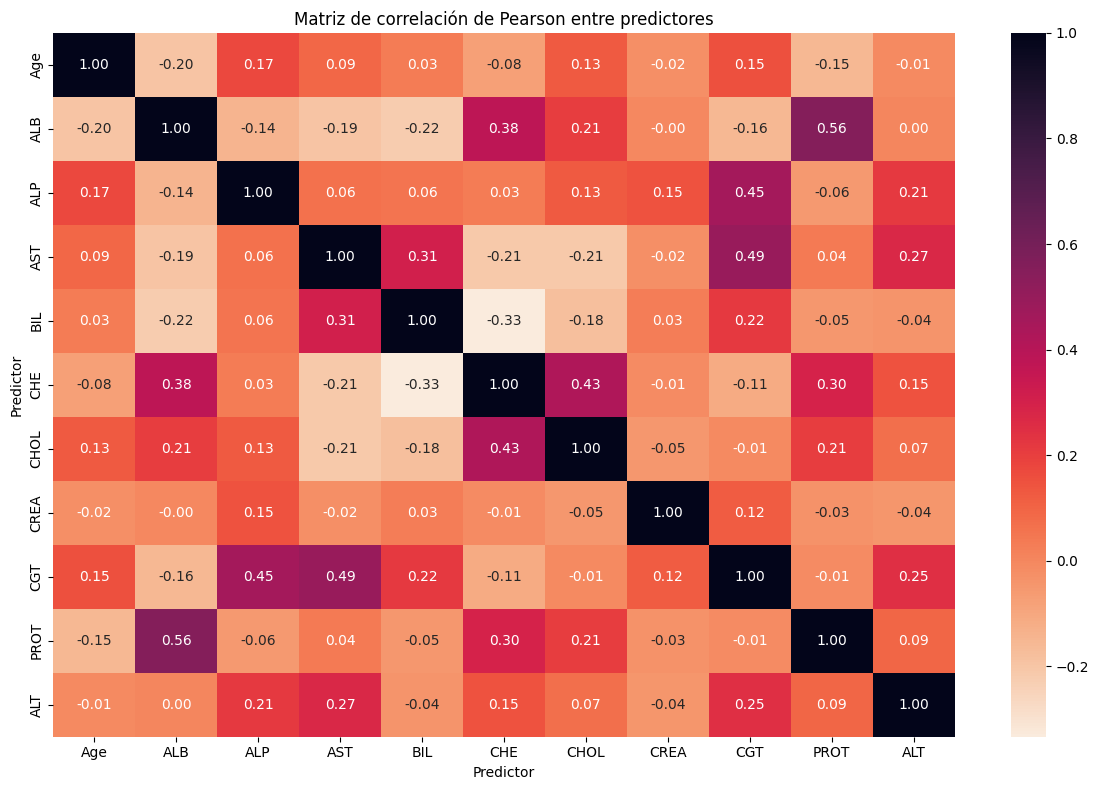

In [45]:
#--- Correlación (lineal) de Pearson entre predictores numéricos
import os
os.makedirs("figs", exist_ok=True)
correl = X.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correl,cmap="rocket_r",annot=True,fmt=".2f")
plt.title("Matriz de correlación de Pearson entre predictores")
plt.xlabel("Predictor")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("figs/multi_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()


   Predictor  Informacion_Mutua
3        AST               0.22
2        ALP               0.15
1        ALB               0.13
4        BIL               0.12
5        CHE               0.11
8        CGT               0.11
10       ALT               0.10
7       CREA               0.07
6       CHOL               0.06
9       PROT               0.05
0        Age               0.03


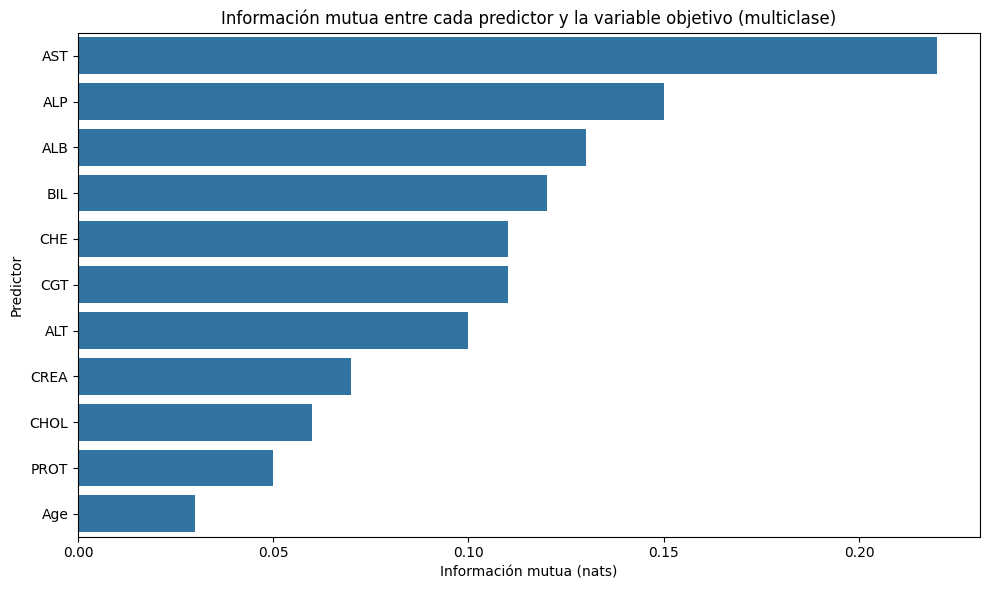

In [46]:
#--- Información mutua de cada predictor respecto a la variable objetivo.
#--- Se calcula solo con X_train, y_train para evitar fuga de información.
import os
os.makedirs("figs", exist_ok=True)
imputacion = Pipeline(steps=[("imputacion", SimpleImputer(strategy="median"))])
X_imp = imputacion.fit_transform(X_train[numericos])
X_imp = pd.DataFrame(X_imp,columns=numericos)

info_mutua = mutual_info_classif(X_imp,y_train,random_state=98)
info_mutua = np.round(info_mutua,2)
info_mutua_df = pd.DataFrame({"Predictor": X_imp.columns,"Informacion_Mutua": info_mutua})
info_mutua_df = info_mutua_df.sort_values(by="Informacion_Mutua",ascending=False)
print(info_mutua_df)

plt.figure(figsize=(10,6))
sns.barplot(data=info_mutua_df,x="Informacion_Mutua",y="Predictor")
plt.title("Información mutua entre cada predictor y la variable objetivo (multiclase)")
plt.xlabel("Información mutua (nats)")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("figs/multi_info_mutua.png", dpi=150, bbox_inches="tight")
plt.show()


2. **Extracción lineal de características mediante PCA.**

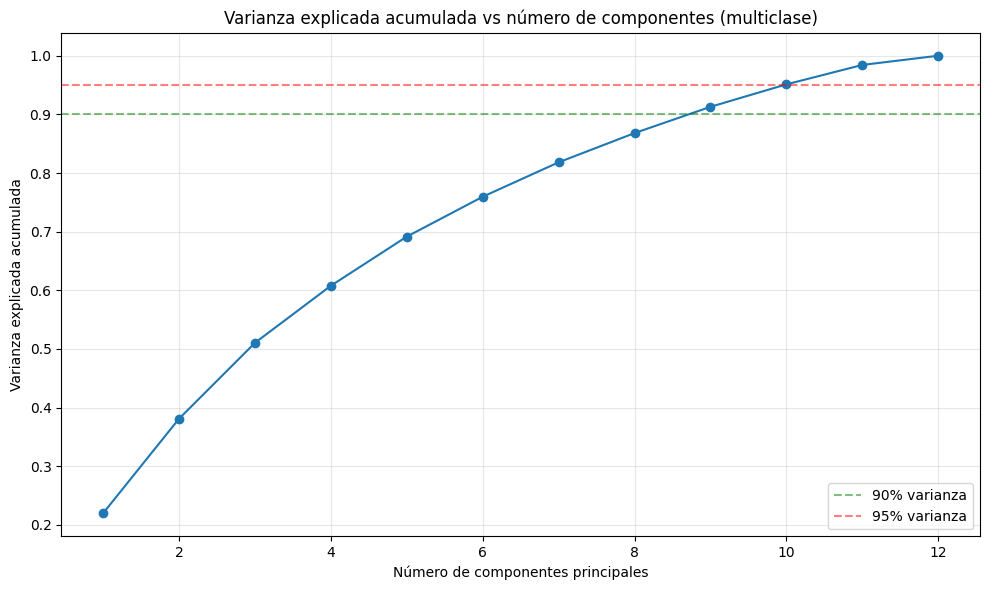

Número de componentes para explicar el 90% de la varianza: 9
Número de componentes para explicar el 95% de la varianza: 10


In [47]:
#--- Varianza explicada acumulada vs número de componentes principales.
import os
os.makedirs("figs", exist_ok=True)
X_train_pre = preprocesador.fit_transform(X_train)
pca_completo = PCA()
pca_completo.fit(X_train_pre)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(np.arange(1, len(varianza_acumulada)+1), varianza_acumulada, marker="o")
plt.axhline(0.90, color="green", linestyle="--", alpha=0.5, label="90% varianza")
plt.axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95% varianza")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada vs número de componentes (multiclase)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/multi_pca_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

var_90 = np.where(varianza_acumulada >= 0.9)[0][0] + 1
print("Número de componentes para explicar el 90% de la varianza:", var_90)
var_95 = np.where(varianza_acumulada >= 0.95)[0][0] + 1
print("Número de componentes para explicar el 95% de la varianza:", var_95)


In [48]:
#--- pipeline PCA + RF + SMOTE con GridSearchCV completo
pipeline_pca90_rf = ImbPipeline([
    ("preprocessor", preprocesador),("pca 90% variance", PCA(n_components=0.9)),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_pca90_rf = GridSearchCV(estimator=pipeline_pca90_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

pipeline_pca95_rf = ImbPipeline([
    ("preprocessor", preprocesador),("pca 95% variance", PCA(n_components=0.95)),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_pca95_rf = GridSearchCV(estimator=pipeline_pca95_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

In [49]:
#--- pipeline PCA + k-NN + ADASYN con GridSearchCV
pipeline_pca90_knn = ImbPipeline([
    ("preprocessor", preprocesador),("pca 90% variance", PCA(n_components=0.9)),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", KNeighborsClassifier())])
malla_pca90_knn = GridSearchCV(estimator=pipeline_pca90_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

pipeline_pca95_knn = ImbPipeline([
    ("preprocessor", preprocesador),("pca 95% variance", PCA(n_components=0.95)),("adasyn", ADASYN(random_state=98,n_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", KNeighborsClassifier())])
malla_pca95_knn = GridSearchCV(estimator=pipeline_pca95_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

In [50]:
#--- entrenamiento
malla_pca90_rf.fit(X_train, y_train)
malla_pca95_rf.fit(X_train, y_train)
evaluar_train_test(malla_pca90_rf, "PCA90 RF SMOTE")
evaluar_train_test(malla_pca95_rf, "PCA95 RF SMOTE")


========= PCA90 RF SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.95      0.97      0.96       107
0s=suspect Blood Donor       0.25      1.00      0.40         1
           1=Hepatitis       0.50      0.20      0.29         5
            2=Fibrosis       0.33      0.25      0.29         4
           3=Cirrhosis       0.75      0.50      0.60         6

              accuracy                           0.89       123
             macro avg       0.56      0.58      0.51       123
          weighted avg       0.89      0.89      0.89       123

--- PCA90 RF SMOTE TRAIN ---
Accuracy: 0.9553
Balanced Accuracy: 0.7864
F1 Macro: 0.793
Precision Macro: 0.8358
Recall Macro: 0.7864
--- PCA90 RF SMOTE TEST ---
Accuracy: 0.8943
Balanced Accuracy: 0.5844
F1 Macro: 0.506
Precision Macro: 0.5558
Recall Macro: 0.5844
GAP F1 (train-test): 0.287

========= PCA95 RF SMOTE =========
REPORTE DE CLASIFICACIÓN 

In [51]:
#--- entrenamiento
malla_pca90_knn.fit(X_train, y_train)
malla_pca95_knn.fit(X_train, y_train)
evaluar_train_test(malla_pca90_knn, "PCA90 k-NN ADASYN")
evaluar_train_test(malla_pca95_knn, "PCA95 k-NN ADASYN")


========= PCA90 k-NN ADASYN =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.92      0.99      0.95       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       0.33      0.20      0.25         5
            2=Fibrosis       1.00      0.25      0.40         4
           3=Cirrhosis       1.00      0.67      0.80         6

              accuracy                           0.91       123
             macro avg       0.65      0.42      0.48       123
          weighted avg       0.90      0.91      0.89       123

--- PCA90 k-NN ADASYN TRAIN ---
Accuracy: 0.9289
Balanced Accuracy: 0.6443
F1 Macro: 0.6662
Precision Macro: 0.7657
Recall Macro: 0.6443
--- PCA90 k-NN ADASYN TEST ---
Accuracy: 0.9106
Balanced Accuracy: 0.4215
F1 Macro: 0.481
Precision Macro: 0.651
Recall Macro: 0.4215
GAP F1 (train-test): 0.1852

========= PCA95 k-NN ADASYN =========
REPORTE DE C

3. **Extracción no lineal de características mediante UMAP.**

In [52]:
#--- pipeline UMAP + RF + SMOTE
pipeline_umap8_rf = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=8,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_umap8_rf = GridSearchCV(estimator=pipeline_umap8_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

pipeline_umap9_rf = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=9,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_umap9_rf = GridSearchCV(estimator=pipeline_umap9_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

UMAP no funciona bien con ADASYN entonces para experimentar utilicé SMOTE.

In [53]:
#--- pipeline UMAP + k-NN + SMOTE
pipeline_umap8_knn = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=8,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", KNeighborsClassifier())])
malla_umap8_knn = GridSearchCV(estimator=pipeline_umap8_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

pipeline_umap9_knn = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=9,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=1,sampling_strategy=sampling_strategy_controlado)),
    ("classifier", KNeighborsClassifier())])
malla_umap9_knn = GridSearchCV(estimator=pipeline_umap9_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

In [54]:
#--- entrenamiento
malla_umap8_rf.fit(X_train, y_train)
malla_umap9_rf.fit(X_train, y_train)
evaluar_train_test(malla_umap8_rf, "UMAP 8C RF SMOTE")
evaluar_train_test(malla_umap9_rf, "UMAP 9C RF SMOTE")

c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



========= UMAP 8C RF SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.90      1.00      0.95       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       0.00      0.00      0.00         5
            2=Fibrosis       0.50      0.25      0.33         4
           3=Cirrhosis       1.00      0.17      0.29         6

              accuracy                           0.89       123
             macro avg       0.48      0.28      0.31       123
          weighted avg       0.85      0.89      0.85       123

--- UMAP 8C RF SMOTE TRAIN ---
Accuracy: 0.9919
Balanced Accuracy: 0.9579
F1 Macro: 0.9755
Precision Macro: 0.9981
Recall Macro: 0.9579
--- UMAP 8C RF SMOTE TEST ---
Accuracy: 0.8862
Balanced Accuracy: 0.2833
F1 Macro: 0.3132
Precision Macro: 0.4798
Recall Macro: 0.2833
GAP F1 (train-test): 0.6623

========= UMAP 9C RF SMOTE =========
REPORTE DE CLA

In [55]:
#--- entrenamiento
malla_umap8_knn.fit(X_train, y_train)
malla_umap9_knn.fit(X_train, y_train)
evaluar_train_test(malla_umap8_knn, "UMAP 8C k-NN SMOTE")
evaluar_train_test(malla_umap9_knn, "UMAP 9C k-NN SMOTE")

c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



========= UMAP 8C k-NN SMOTE =========
REPORTE DE CLASIFICACIÓN (TEST)
                        precision    recall  f1-score   support

         0=Blood Donor       0.91      1.00      0.95       107
0s=suspect Blood Donor       0.00      0.00      0.00         1
           1=Hepatitis       0.00      0.00      0.00         5
            2=Fibrosis       0.50      0.25      0.33         4
           3=Cirrhosis       0.50      0.17      0.25         6

              accuracy                           0.89       123
             macro avg       0.38      0.28      0.31       123
          weighted avg       0.83      0.89      0.85       123

--- UMAP 8C k-NN SMOTE TRAIN ---
Accuracy: 0.9919
Balanced Accuracy: 0.9579
F1 Macro: 0.9755
Precision Macro: 0.9981
Recall Macro: 0.9579
--- UMAP 8C k-NN SMOTE TEST ---
Accuracy: 0.8862
Balanced Accuracy: 0.2833
F1 Macro: 0.3069
Precision Macro: 0.3814
Recall Macro: 0.2833
GAP F1 (train-test): 0.6686

========= UMAP 9C k-NN SMOTE =========
REPORT

TABLA COMPARATIVA Y DIAGNÓSTICO DE SOBREAJUSTE

In [56]:
#--- recopilación de todos los modelos para comparación final.
modelos = {
    "Logit SMOTE": malla_logit_smote,
    "Logit ADASYN": malla_logit_adasyn,
    "k-NN SMOTE": malla_knn_smote,
    "k-NN ADASYN": malla_knn_adasyn,
    "RF SMOTE": malla_rf_smote,
    "RF ADASYN": malla_rf_adasyn,
    "SVC SMOTE": malla_svc_smote,
    "SVC ADASYN": malla_svc_adasyn,
    "MLP SMOTE": malla_mlp_smote,
    "MLP ADASYN": malla_mlp_adasyn,
    "HGB SMOTE": malla_hgb_smote,
    "HGB ADASYN": malla_hgb_adasyn,
    "PCA90 RF": malla_pca90_rf,
    "PCA95 RF": malla_pca95_rf,
    "PCA90 k-NN": malla_pca90_knn,
    "PCA95 k-NN": malla_pca95_knn,
    "UMAP8 RF": malla_umap8_rf,
    "UMAP9 RF": malla_umap9_rf,
    "UMAP8 k-NN": malla_umap8_knn,
    "UMAP9 k-NN": malla_umap9_knn,
    "BRF": malla_brf,
}

filas = []
for nombre, m in modelos.items():
    yp_tr = m.predict(X_train)
    yp_te = m.predict(X_test)
    f1_tr = f1_score(y_train, yp_tr, average="macro", zero_division=0)
    f1_te = f1_score(y_test, yp_te, average="macro", zero_division=0)
    ba_te = balanced_accuracy_score(y_test, yp_te)
    acc_te = accuracy_score(y_test, yp_te)
    filas.append({
        "Modelo": nombre,
        "F1 Macro CV": round(m.best_score_, 4),
        "F1 Macro Train": round(f1_tr, 4),
        "F1 Macro Test": round(f1_te, 4),
        "Gap Train-Test": round(f1_tr - f1_te, 4),
        "Balanced Acc Test": round(ba_te, 4),
        "Accuracy Test": round(acc_te, 4),
    })

tabla = pd.DataFrame(filas).sort_values(by="F1 Macro Test", ascending=False).reset_index(drop=True)
display(tabla)

,Modelo,F1 Macro CV,F1 Macro Train,F1 Macro Test,Gap Train-Test,Balanced Acc Test,Accuracy Test
0,RF ADASYN,0.5807,0.7921,0.7999,-0.0078,0.7733,0.9512
1,SVC SMOTE,0.5869,0.7818,0.6838,0.0979,0.6367,0.9593
2,SVC ADASYN,0.5825,0.8023,0.6838,0.1185,0.6367,0.9593
3,BRF,0.6179,0.8043,0.6812,0.1232,0.7921,0.9106
4,MLP SMOTE,0.6196,0.9715,0.6601,0.3114,0.6396,0.9431
5,MLP ADASYN,0.6110,0.9773,0.6577,0.3196,0.6396,0.9431
6,RF SMOTE,0.6046,0.8782,0.6475,0.2307,0.6133,0.9512
7,PCA95 RF,0.5316,0.8345,0.6409,0.1936,0.6733,0.9350
8,HGB ADASYN,0.5594,0.8987,0.6406,0.2581,0.6033,0.9512
9,Logit SMOTE,0.6093,0.7537,0.6403,0.1135,0.5633,0.9431


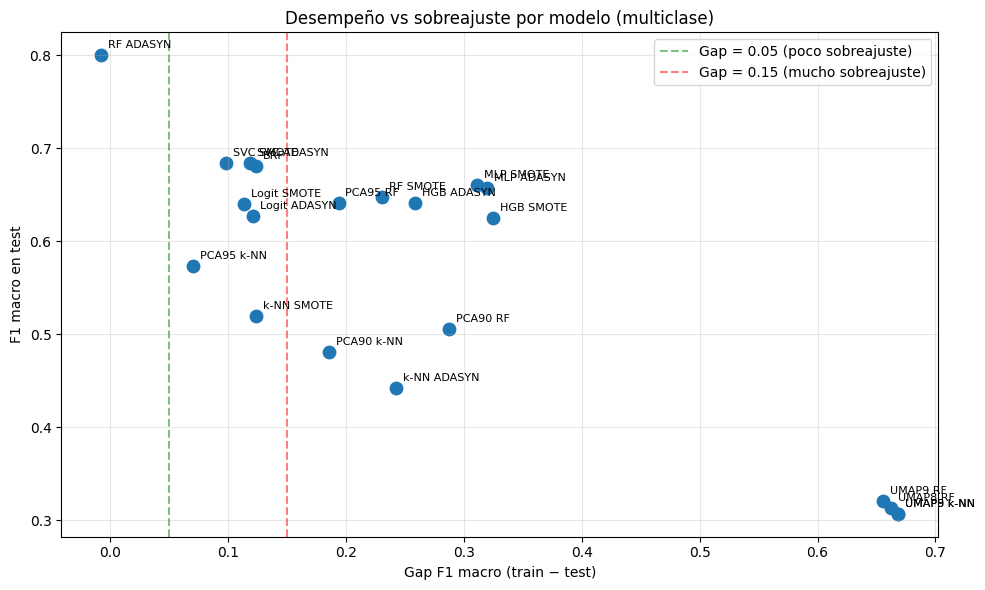

In [57]:
#--- Gráfica diagnóstica: F1 macro test vs Gap (train-test). Ideal: alto F1 y bajo gap.
import os
os.makedirs("figs", exist_ok=True)
plt.figure(figsize=(10,6))
plt.scatter(tabla["Gap Train-Test"], tabla["F1 Macro Test"], s=80)
for i, row in tabla.iterrows():
    plt.annotate(row["Modelo"], (row["Gap Train-Test"], row["F1 Macro Test"]),
                 fontsize=8, xytext=(5,5), textcoords="offset points")
plt.axvline(0.05, color="green", linestyle="--", alpha=0.5, label="Gap = 0.05 (poco sobreajuste)")
plt.axvline(0.15, color="red", linestyle="--", alpha=0.5, label="Gap = 0.15 (mucho sobreajuste)")
plt.xlabel("Gap F1 macro (train − test)")
plt.ylabel("F1 macro en test")
plt.title("Desempeño vs sobreajuste por modelo (multiclase)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/multi_scatter_f1_gap.png", dpi=150, bbox_inches="tight")
plt.show()


**Curva de aprendizaje del mejor modelo**

Curva de aprendizaje para: RF ADASYN


c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to 0.0.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Usuario\Documents

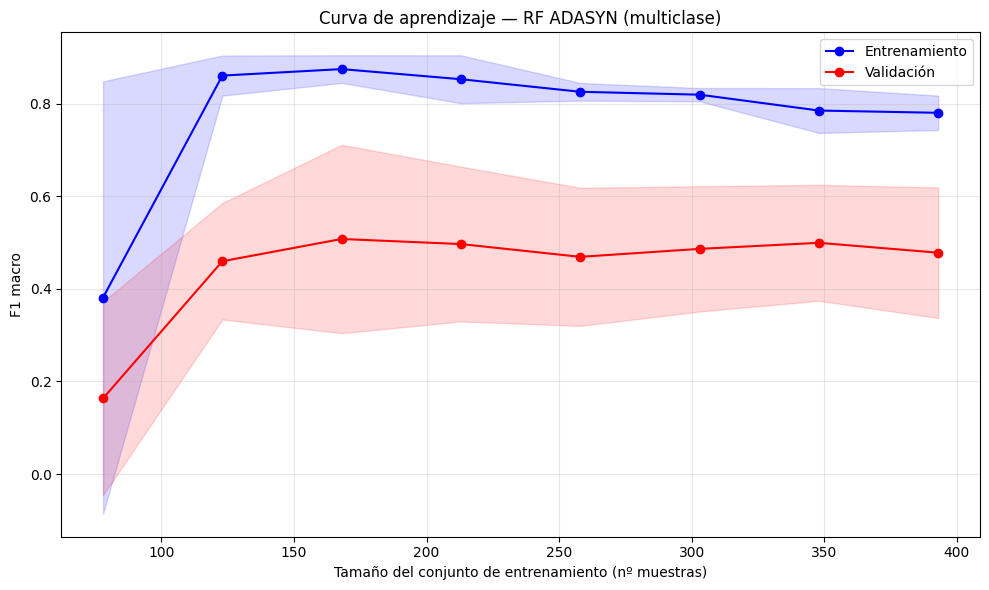

In [58]:
#--- Curva de aprendizaje del modelo con mejor F1 macro en test.
os.makedirs("figs", exist_ok=True)
mejor_nombre = tabla.iloc[0]["Modelo"]
mejor_modelo = modelos[mejor_nombre].best_estimator_
print(f"Curva de aprendizaje para: {mejor_nombre}")

sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=98),
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1, random_state=98, error_score=0.0)

train_mean = train_scores.mean(axis=1); train_std = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1);   val_std   = val_scores.std(axis=1)

plt.figure(figsize=(10,6))
plt.plot(sizes, train_mean, "o-", color="blue", label="Entrenamiento")
plt.fill_between(sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color="blue")
plt.plot(sizes, val_mean, "o-", color="red", label="Validación")
plt.fill_between(sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color="red")
plt.xlabel("Tamaño del conjunto de entrenamiento (nº muestras)")
plt.ylabel("F1 macro")
plt.title(f"Curva de aprendizaje — {mejor_nombre} (multiclase)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/multi_curva_aprendizaje.png", dpi=150, bbox_inches="tight")
plt.show()


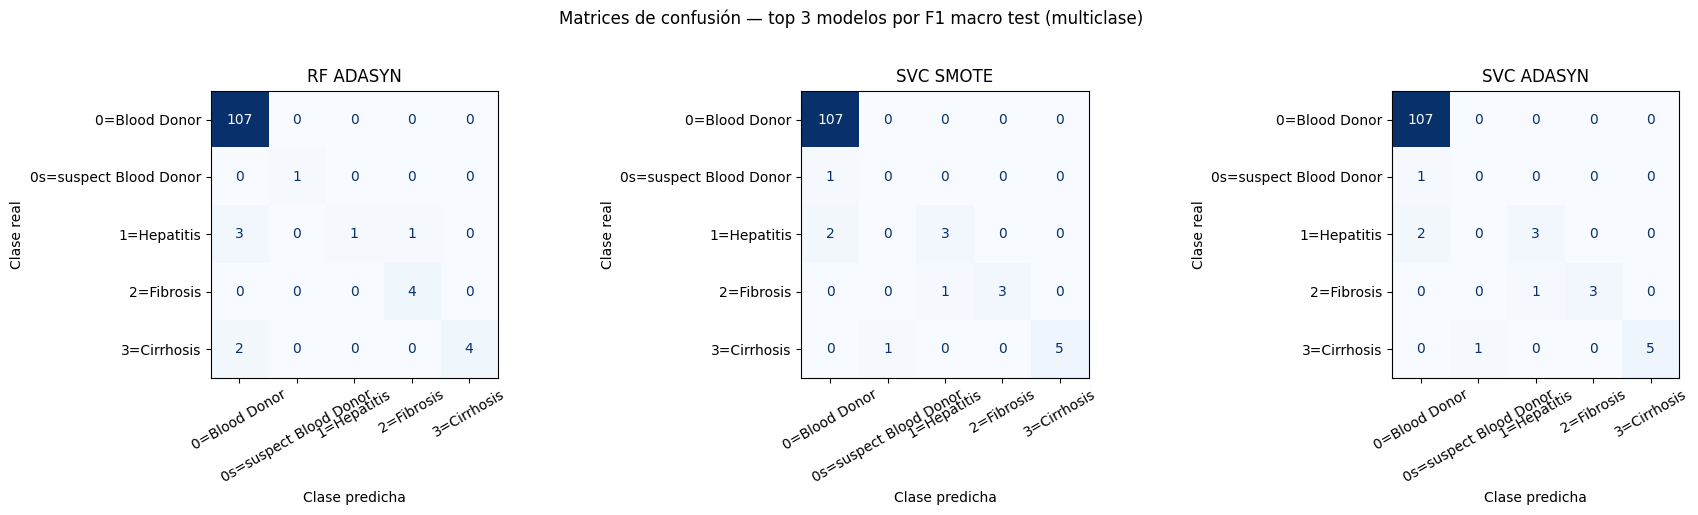

In [59]:
#--- Matrices de confusión de los 3 mejores modelos según F1 macro en test.
os.makedirs("figs", exist_ok=True)
top3 = tabla.head(3)["Modelo"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nombre in zip(axes, top3):
    modelo = modelos[nombre]
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, xticks_rotation=30, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
fig.suptitle("Matrices de confusión — top 3 modelos por F1 macro test (multiclase)", y=1.02)
plt.tight_layout()
plt.savefig("figs/multi_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


### INTERVALOS DE CONFIANZA AL 95% (t-Student) sobre LAS MÉTRICAS DE DESEMPEÑO

Para cada modelo se ejecuta `cross_validate` con el `best_estimator_` ya obtenido del `GridSearchCV`,
usando el mismo objeto `cv` (RepeatedStratifiedKFold 3×5) y un *scoring dict* multi-métrico.
A partir de los scores por fold se computa media, desviación estándar (muestral),
error estándar de la media y el intervalo de confianza al 95% con la t-Student
de $n-1$ grados de libertad ($n=15$).


In [61]:
#--- IC al 95% sobre las múltiples métricas de desempeño (multiclase).
#--- Se ejecuta cross_validate sobre el best_estimator_ de cada GridSearchCV
#--- reusando el mismo cv (RepeatedStratifiedKFold 3x5) para obtener scores
#--- por fold de cada metrica. Luego se calcula la media, sd, SEM e IC95%
#--- con t-Student (df = n - 1).

scoring_multi = {
    "F1 macro":          "f1_macro",
    "Balanced accuracy": "balanced_accuracy",
    "Accuracy":          "accuracy",
    "Precision macro":   "precision_macro",
    "Recall macro":      "recall_macro",
}

def ic_t(scores, alpha=0.05):
    """Devuelve (media, sd, sem, IC_inf, IC_sup) para un array de scores."""
    s = np.asarray(scores, dtype=float)
    s = s[~np.isnan(s)]
    n = len(s)
    if n < 2:
        return (float("nan"),) * 5
    media = float(s.mean())
    sd = float(s.std(ddof=1))
    sem = sd / np.sqrt(n)
    tc = float(stats.t.ppf(1 - alpha/2, df=n-1))
    margen = tc * sem
    return media, sd, sem, media - margen, media + margen

#--- Cálculo de IC por (modelo, métrica)
filas = []
for nombre, grid in modelos.items():
    print(f"Procesando: {nombre} ...")
    try:
        res = cross_validate(
            grid.best_estimator_, X_train, y_train,
            scoring=scoring_multi, cv=cv,
            n_jobs=-1, return_train_score=False, error_score=np.nan,
        )
    except Exception as e:
        print(f"  [!] error en {nombre}: {e}")
        continue
    for nombre_metrica, key in scoring_multi.items():
        scores = res[f"test_{nombre_metrica}"]
        media, sd, sem, li, ls = ic_t(scores)
        filas.append({
            "Modelo": nombre,
            "Métrica": nombre_metrica,
            "Media (CV)":  round(media, 4),
            "SD":          round(sd, 4),
            "SEM":         round(sem, 4),
            "IC 95% inf":  round(li, 4),
            "IC 95% sup":  round(ls, 4),
            "Amplitud IC": round(ls - li, 4),
            "n_folds":     int(np.sum(~np.isnan(scores))),
            "Reporte":     f"{media:.3f} [{li:.3f}, {ls:.3f}]",
        })

tabla_ic_long = pd.DataFrame(filas)
print("\n=== Tabla de IC (formato largo) ===")
display(tabla_ic_long)

#--- Pivot a formato ancho (un modelo por fila, una columna por métrica) para el informe.
tabla_ic_wide = tabla_ic_long.pivot(index="Modelo", columns="Métrica", values="Reporte")
tabla_ic_wide = tabla_ic_wide.reindex(columns=list(scoring_multi.keys()))

#--- Orden por F1 macro descendente (extrayendo la media del string).
orden = (tabla_ic_long[tabla_ic_long["Métrica"] == "F1 macro"]
         .sort_values("Media (CV)", ascending=False)["Modelo"].tolist())
tabla_ic_wide = tabla_ic_wide.reindex(orden)

print("\n=== Tabla de IC ===")
display(tabla_ic_wide)


Procesando: Logit SMOTE ...
Procesando: Logit ADASYN ...
Procesando: k-NN SMOTE ...
Procesando: k-NN ADASYN ...
Procesando: RF SMOTE ...
Procesando: RF ADASYN ...
Procesando: SVC SMOTE ...
Procesando: SVC ADASYN ...
Procesando: MLP SMOTE ...
Procesando: MLP ADASYN ...
Procesando: HGB SMOTE ...
Procesando: HGB ADASYN ...
Procesando: PCA90 RF ...
Procesando: PCA95 RF ...
Procesando: PCA90 k-NN ...
Procesando: PCA95 k-NN ...
Procesando: UMAP8 RF ...
Procesando: UMAP9 RF ...
Procesando: UMAP8 k-NN ...
Procesando: UMAP9 k-NN ...
Procesando: BRF ...

=== Tabla de IC (formato largo) ===


,Modelo,Métrica,Media (CV),SD,SEM,IC 95% inf,IC 95% sup,Amplitud IC,n_folds,Reporte
0,Logit SMOTE,F1 macro,0.6093,0.0809,0.0209,0.5645,0.6541,0.0896,15,"0.609 [0.565, 0.654]"
1,Logit SMOTE,Balanced accuracy,0.5762,0.0840,0.0217,0.5297,0.6227,0.0930,15,"0.576 [0.530, 0.623]"
2,Logit SMOTE,Accuracy,0.9244,0.0128,0.0033,0.9173,0.9315,0.0142,15,"0.924 [0.917, 0.931]"
3,Logit SMOTE,Precision macro,0.6883,0.0967,0.0250,0.6348,0.7419,0.1071,15,"0.688 [0.635, 0.742]"
4,Logit SMOTE,Recall macro,0.5762,0.0840,0.0217,0.5297,0.6227,0.0930,15,"0.576 [0.530, 0.623]"
...,...,...,...,...,...,...,...,...,...,...
100,BRF,F1 macro,0.6179,0.0444,0.0115,0.5933,0.6425,0.0492,15,"0.618 [0.593, 0.642]"
101,BRF,Balanced accuracy,0.6886,0.0682,0.0176,0.6508,0.7264,0.0756,15,"0.689 [0.651, 0.726]"
102,BRF,Accuracy,0.8841,0.0238,0.0062,0.8709,0.8973,0.0264,15,"0.884 [0.871, 0.897]"
103,BRF,Precision macro,0.6103,0.0557,0.0144,0.5794,0.6411,0.0617,15,"0.610 [0.579, 0.641]"



=== Tabla de IC ===


Métrica,F1 macro,Balanced accuracy,Accuracy,Precision macro,Recall macro
Modelo,,,,,
MLP SMOTE,"0.620 [0.586, 0.653]","0.604 [0.567, 0.641]","0.922 [0.915, 0.929]","0.691 [0.647, 0.735]","0.604 [0.567, 0.641]"
BRF,"0.618 [0.593, 0.642]","0.689 [0.651, 0.726]","0.884 [0.871, 0.897]","0.610 [0.579, 0.641]","0.689 [0.651, 0.726]"
MLP ADASYN,"0.611 [0.560, 0.662]","0.610 [0.552, 0.668]","0.921 [0.913, 0.928]","0.643 [0.593, 0.694]","0.610 [0.552, 0.668]"
Logit ADASYN,"0.610 [0.559, 0.661]","0.578 [0.526, 0.630]","0.923 [0.915, 0.931]","0.683 [0.622, 0.744]","0.578 [0.526, 0.630]"
Logit SMOTE,"0.609 [0.565, 0.654]","0.576 [0.530, 0.623]","0.924 [0.917, 0.931]","0.688 [0.635, 0.742]","0.576 [0.530, 0.623]"
RF SMOTE,"0.605 [0.554, 0.655]","0.578 [0.523, 0.634]","0.922 [0.914, 0.930]","0.682 [0.618, 0.745]","0.578 [0.523, 0.634]"
SVC SMOTE,"0.587 [0.537, 0.637]","0.551 [0.506, 0.595]","0.918 [0.910, 0.926]","0.681 [0.613, 0.749]","0.551 [0.506, 0.595]"
HGB SMOTE,"0.585 [0.534, 0.637]","0.574 [0.521, 0.627]","0.922 [0.915, 0.930]","0.646 [0.583, 0.709]","0.574 [0.521, 0.627]"
SVC ADASYN,"0.583 [0.527, 0.638]","0.549 [0.495, 0.603]","0.916 [0.908, 0.925]","0.666 [0.594, 0.738]","0.549 [0.495, 0.603]"
